<a href="https://colab.research.google.com/github/Gaurav-Rawool/Machin-learning/blob/main/Gaurav__ML__Experiment__8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name :Gaurav Rawool

Batch : CE-03


Roll Number : CE-39



### **Aim**

To implement graph-based clustering using Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset in Python and visualize the resulting clusters.

## Objectives

1. To understand the concept of graph-based clustering and Minimum Spanning Trees (MST).
2. To load and preprocess the Breast Cancer Wisconsin dataset (scaling features and handling metadata).
3. To construct a distance graph from tumor feature representations using Euclidean distance.
4. To compute the Minimum Spanning Tree using Prim's or Kruskal's algorithm (or via scipy/networkx).
5. To form $K=2$ clusters (Malignant vs. Benign) by removing the single ($K - 1$) largest edge weight from the MST.
6. To evaluate the performance of the MST-based clustering model using evaluation metrics.

# Relevant Theory

###Graph-Based Clustering & Minimum Spanning Tree (MST)
Graph-based clustering represents data points as nodes in a graph, with edges representing relationships or distance metrics between individual samples.
* **Complete Graph Construction**: Given a dataset $X = \{x_1, x_2, \dots, x_n\}$,
each tissue sample is treated as a vertex. An edge weight $w(i, j)$ corresponds to the distance between sample $i$ and sample $j$ (typically Euclidean distance on scaled features):$$w(i, j) = \Vert{}x_i - x_j\Vert{}_2$$
* **Minimum Spanning Tree (MST)**: An MST is a subset of edges connecting all vertices in the graph without forming any cycles, while minimizing the total edge weight sum.
* **MST-Based Clustering Method**:
  1. Construct a fully connected graph with pairwise edge weights across standardized features.
  2. Compute the Minimum Spanning Tree (MST).
  3. To partition the data into $K$ distinct clusters (such as Malignant and Benign groups), identify and remove the $K - 1$ largest (most expensive) edges from the MST.4. The resulting disconnected subgraphs represent the separate data clusters.
### Dataset Information
Get the Breast Cancer Wisconsin (Diagnostic) dataset from Kaggle or via scikit-learn (load_breast_cancer).
The dataset contains key cell nuclei features computed from digitized images of fine needle aspirates (FNA) of breast masses:
  * Total Instances: 569 samples
  * Target Classes: Malignant (M) and Benign (B)* Feature Attributes: 30 numerical features (e.g., mean radius, mean texture, mean perimeter, mean area, mean smoothness)

For 2D visualization, two key features (such as mean radius and mean texture) will be selected.

# Task 1: Import Libraries and Load Dataset

* Import required libraries (numpy, pandas, matplotlib, scipy, networkx, sklearn).

* Load the Breast Cancer dataset using below link from Kaggle.

  https://www.kaggle.com/datasets/utkarshx27/breast-cancer-wisconsin-diagnostic-dataset

---

In [1]:
# Task 1: Import Libraries and Load Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import minimum_spanning_tree, connected_components

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

# Upload CSV file
from google.colab import files

print("Please upload the Breast Cancer CSV dataset:")
uploaded = files.upload()

# Get uploaded file name
file_name = next(iter(uploaded))

# Read CSV file
df = pd.read_csv(file_name)

print("\nFile uploaded successfully:", file_name)
print("Dataset Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

Please upload the Breast Cancer CSV dataset:


Saving brca.csv to brca.csv

File uploaded successfully: brca.csv
Dataset Shape: (569, 32)

First 5 rows:


,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


# Task 2: Explore the Dataset

* Display missing value checks, summary statistics, and feature dimensions.

* Check the diagnosis class distribution (Malignant vs. Benign).

Dataset Shape:
(569, 32)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           569 non-null    int64  
 1   x.radius_mean        569 non-null    float64
 2   x.texture_mean       569 non-null    float64
 3   x.perimeter_mean     569 non-null    float64
 4   x.area_mean          569 non-null    float64
 5   x.smoothness_mean    569 non-null    float64
 6   x.compactness_mean   569 non-null    float64
 7   x.concavity_mean     569 non-null    float64
 8   x.concave_pts_mean   569 non-null    float64
 9   x.symmetry_mean      569 non-null    float64
 10  x.fractal_dim_mean   569 non-null    float64
 11  x.radius_se          569 non-null    float64
 12  x.texture_se         569 non-null    float64
 13  x.perimeter_se       569 non-null    float64
 14  x.area_se            569 non-null    float6

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,285.000000,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,164.400426,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,1.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,143.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,285.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,427.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,569.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500



Diagnosis Class Distribution:
y
B    357
M    212
Name: count, dtype: int64


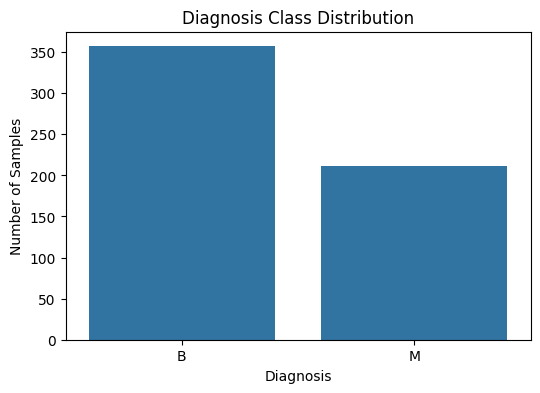

In [2]:
# Task 2: Explore the Dataset

print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nMissing Values in Each Column:")
print(df.isnull().sum())

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

print("\nSummary Statistics:")
display(df.describe())

print("\nDiagnosis Class Distribution:")
print(df['y'].value_counts())

# Plot diagnosis distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df)

plt.title("Diagnosis Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")

plt.show()

# Task 3: Preprocess and Scale Features

* Select numerical features and drop non-informative identifiers (such as id).

* Apply StandardScaler to normalize feature magnitudes prior to graph distance calculation.

In [3]:
# Task 3: Preprocess and Scale Features

from sklearn.preprocessing import StandardScaler

# Remove identifier column and separate target
X = df.drop(columns=['Unnamed: 0', 'y'])
y = df['y'].map({'B': 0, 'M': 1})

print("Original Feature Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nNumber of Features:", X.shape[1])

print("\nTarget Distribution:")
print(y.value_counts())

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nScaled Feature Shape:", X_scaled.shape)

print("\nMean of standardized features:")
print(np.round(X_scaled.mean(axis=0), 4))

print("\nStandard deviation of standardized features:")
print(np.round(X_scaled.std(axis=0), 4))

Original Feature Shape: (569, 30)
Target Shape: (569,)

Number of Features: 30

Target Distribution:
y
0    357
1    212
Name: count, dtype: int64

Scaled Feature Shape: (569, 30)

Mean of standardized features:
[-0. -0. -0. -0.  0.  0.  0.  0.  0.  0.  0. -0.  0. -0. -0.  0. -0.  0.
  0. -0. -0.  0.  0. -0. -0.  0.  0.  0.  0.  0.]

Standard deviation of standardized features:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


# Task 4: Construct Pairwise Distance Matrix & Graph

* Compute pairwise Euclidean distance matrix across all scaled samples using scipy.spatial.distance.pdist or cdist.

* Represent the dataset as a weighted complete graph.

In [4]:
# Task 4: Construct Pairwise Distance Matrix & Graph

from scipy.spatial.distance import pdist, squareform
import networkx as nx

# Calculate pairwise Euclidean distances
distance_vector = pdist(X_scaled, metric='euclidean')

# Convert distances into a square matrix
distance_matrix = squareform(distance_vector)

print("Pairwise Distance Matrix Shape:")
print(distance_matrix.shape)

print("\nFirst 5 × 5 Distance Matrix:")
print(np.round(distance_matrix[:5, :5], 2))

# Create complete weighted graph
G_complete = nx.Graph()

# Add all samples as nodes
G_complete.add_nodes_from(range(len(X_scaled)))

# Add weighted edges
for i in range(len(X_scaled)):
    for j in range(i + 1, len(X_scaled)):
        G_complete.add_edge(
            i,
            j,
            weight=distance_matrix[i, j]
        )

print("\nComplete Graph Information:")
print("Number of Nodes:", G_complete.number_of_nodes())
print("Number of Edges:", G_complete.number_of_edges())

Pairwise Distance Matrix Shape:
(569, 569)

First 5 × 5 Distance Matrix:
[[0.   3.11 3.62 5.2  4.47]
 [3.11 0.   4.01 5.62 4.37]
 [3.62 4.01 0.   5.12 2.95]
 [5.2  5.62 5.12 0.   5.03]
 [4.47 4.37 2.95 5.03 0.  ]]

Complete Graph Information:
Number of Nodes: 569
Number of Edges: 161596


# Task 5: Compute the Minimum Spanning Tree (MST)

* Compute the MST using scipy.sparse.csgraph.minimum_spanning_tree or networkx.minimum_spanning_tree.

* Extract the resulting graph connections and weights.

In [5]:
# Task 5: Compute Minimum Spanning Tree (MST)

from scipy.sparse.csgraph import minimum_spanning_tree
import networkx as nx

# Compute MST from the distance matrix
mst = minimum_spanning_tree(distance_matrix)

# Convert MST to NetworkX graph
G_mst = nx.Graph()

# Add all nodes
G_mst.add_nodes_from(range(len(X_scaled)))

# Extract MST edges
mst_edges = []

coo = mst.tocoo()

for i, j, weight in zip(coo.row, coo.col, coo.data):
    G_mst.add_edge(
        int(i),
        int(j),
        weight=float(weight)
    )

    mst_edges.append(
        (int(i), int(j), float(weight))
    )

print("Minimum Spanning Tree Information")
print("----------------------------------")
print("Number of Nodes:", G_mst.number_of_nodes())
print("Number of MST Edges:", G_mst.number_of_edges())

# Sort edges by weight in descending order
mst_edges_sorted = sorted(
    mst_edges,
    key=lambda x: x[2],
    reverse=True
)

print("\n10 Largest MST Edges:")
for edge in mst_edges_sorted[:10]:
    print(
        f"Node {edge[0]} -- Node {edge[1]} : "
        f"Weight = {edge[2]:.4f}"
    )

Minimum Spanning Tree Information
----------------------------------
Number of Nodes: 569
Number of MST Edges: 568

10 Largest MST Edges:
Node 544 -- Node 553 : Weight = 12.2999
Node 18 -- Node 69 : Weight = 10.4761
Node 48 -- Node 468 : Weight = 8.8264
Node 467 -- Node 544 : Weight = 8.2685
Node 424 -- Node 429 : Weight = 8.0780
Node 360 -- Node 454 : Weight = 7.8710
Node 18 -- Node 208 : Weight = 7.7911
Node 412 -- Node 515 : Weight = 7.0895
Node 454 -- Node 515 : Weight = 7.0626
Node 369 -- Node 395 : Weight = 6.9690


# Task 6: Implement Graph-Based Clustering ($K=2$)

* Sort the edges of the MST in descending order by edge weight.
* Remove the largest $K - 1$ edge (1 largest edge for 2 clusters) to split the MST into 2 connected components.
* Assign final cluster labels based on the resulting component indices.


In [6]:
# Task 6: Graph-Based Clustering (K = 2)

K = 2

# Create a copy of the MST
G_cluster = G_mst.copy()

# Sort MST edges in descending order of weight
sorted_edges = sorted(
    G_cluster.edges(data=True),
    key=lambda x: x[2]['weight'],
    reverse=True
)

# Remove K-1 largest edges
edges_to_remove = sorted_edges[:K-1]

print("Edge Removed:")
for u, v, data in edges_to_remove:
    print(
        f"Node {u} -- Node {v} : "
        f"Weight = {data['weight']:.4f}"
    )

    G_cluster.remove_edge(u, v)

# Find connected components
components = list(nx.connected_components(G_cluster))

print("\nNumber of Clusters:", len(components))

# Assign cluster labels
cluster_labels = np.zeros(len(X_scaled), dtype=int)

for cluster_id, component in enumerate(components):
    for sample_index in component:
        cluster_labels[sample_index] = cluster_id

# Display cluster sizes
print("\nCluster Sizes:")

for cluster_id in range(len(components)):
    size = np.sum(cluster_labels == cluster_id)
    print(f"Cluster {cluster_id}: {size} samples")

Edge Removed:
Node 544 -- Node 553 : Weight = 12.2999

Number of Clusters: 2

Cluster Sizes:
Cluster 0: 567 samples
Cluster 1: 2 samples


# Task 7: valuate MST Clustering Performance

Evaluate cluster assignment against ground truth labels using:

  *  Silhouette Score

  *  Adjusted Rand Index (ARI)

  *  Normalized Mutual Information (NMI)

In [7]:
# Task 7: Evaluate MST Clustering Performance

from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

# Silhouette Score
silhouette = silhouette_score(
    X_scaled,
    cluster_labels
)

# Adjusted Rand Index
ari = adjusted_rand_score(
    y,
    cluster_labels
)

# Normalized Mutual Information
nmi = normalized_mutual_info_score(
    y,
    cluster_labels
)

print("MST Clustering Evaluation")
print("--------------------------")

print(f"Silhouette Score        : {silhouette:.4f}")
print(f"Adjusted Rand Index     : {ari:.4f}")
print(f"Normalized Mutual Info  : {nmi:.4f}")

MST Clustering Evaluation
--------------------------
Silhouette Score        : 0.6607
Adjusted Rand Index     : 0.0048
Normalized Mutual Info  : 0.0102


# Task 8: Visualize MST and Graph-Based Clusters

* Select two representative features (e.g., mean radius vs. mean texture) for 2D plotting.
 * Plot 1: Unclustered standardized data points.
* Plot 2: Minimum Spanning Tree (MST) edge connections overlaid on the data.
* Plot 3: Final clusters formed after cutting the $K - 1$ largest edge(s).

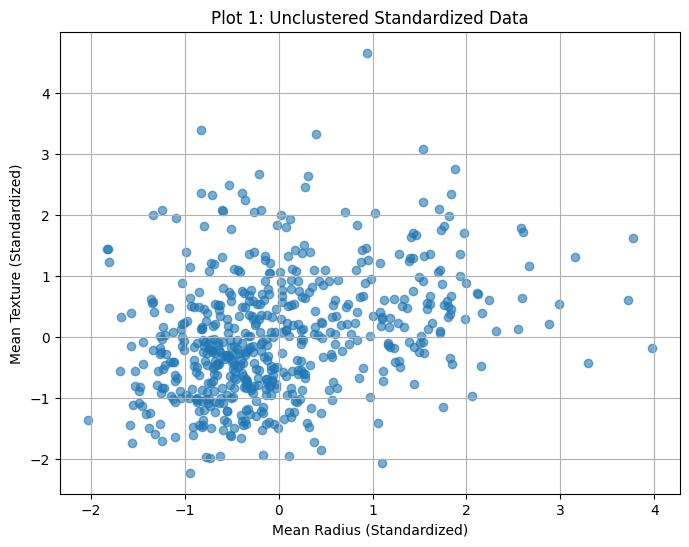

Number of MST edges: 568


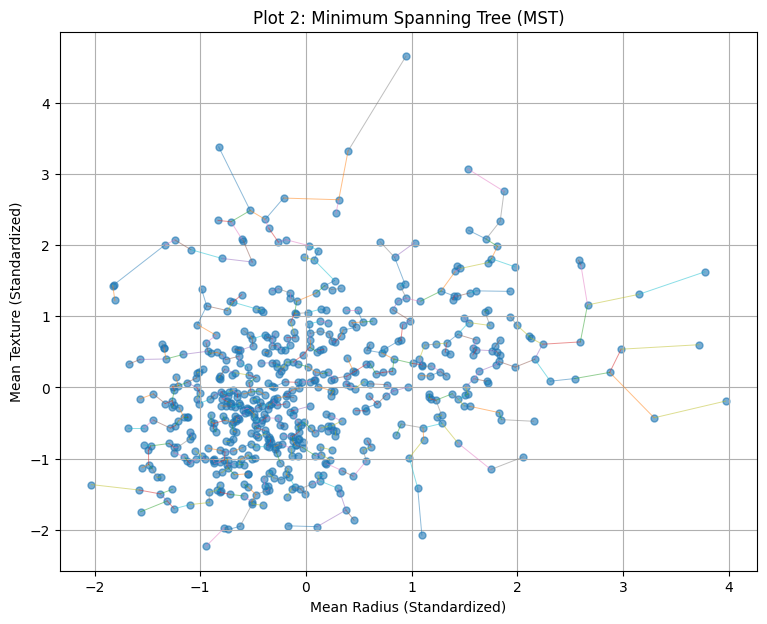


Largest edges removed:
Edge (239, 259) -> Distance = 1.4395
Edge (232, 473) -> Distance = 0.9420

Number of clusters formed: 3


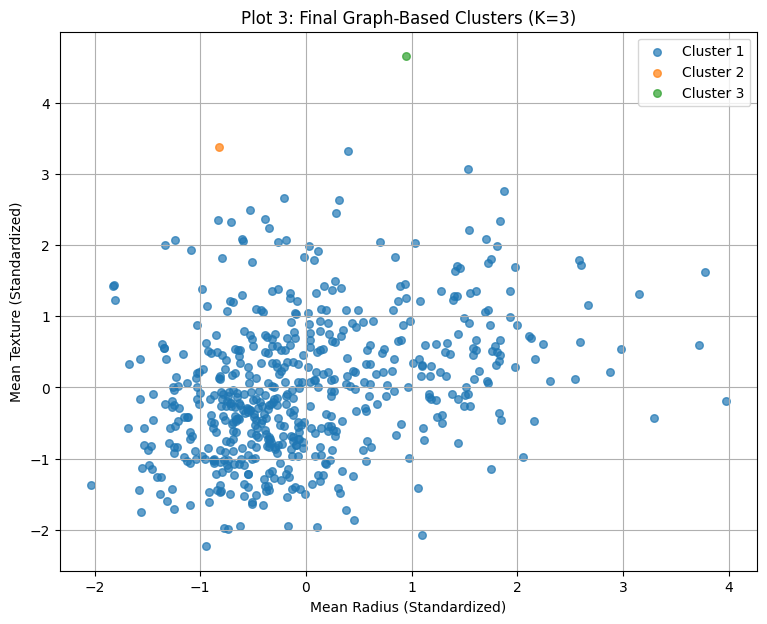

In [8]:
# Task 8: Visualize MST and Graph-Based Clusters

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import connected_components

# ---------------------------------------------------------
# 1. Load Breast Cancer Wisconsin Dataset
# ---------------------------------------------------------
data = load_breast_cancer()

# Select two representative features
# mean radius = column 0
# mean texture = column 1
X = data.data[:, [0, 1]]

# Standardize the selected features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------------------------------------
# 2. Plot 1: Unclustered Standardized Data
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    alpha=0.6
)

plt.xlabel("Mean Radius (Standardized)")
plt.ylabel("Mean Texture (Standardized)")
plt.title("Plot 1: Unclustered Standardized Data")
plt.grid(True)

plt.show()

# ---------------------------------------------------------
# 3. Calculate Pairwise Euclidean Distances
# ---------------------------------------------------------
distance_matrix = squareform(pdist(X_scaled, metric="euclidean"))

# ---------------------------------------------------------
# 4. Construct Minimum Spanning Tree
# ---------------------------------------------------------
mst = minimum_spanning_tree(distance_matrix)

# Convert MST to dense matrix
mst_matrix = mst.toarray()

# Extract MST edges
edges = []

for i in range(len(X_scaled)):
    for j in range(len(X_scaled)):
        if mst_matrix[i, j] > 0:
            edges.append((i, j, mst_matrix[i, j]))

print("Number of MST edges:", len(edges))

# ---------------------------------------------------------
# 5. Plot 2: MST Edges Over Data
# ---------------------------------------------------------
plt.figure(figsize=(9, 7))

# Plot data points
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    alpha=0.6,
    s=25
)

# Draw MST edges
for i, j, weight in edges:
    plt.plot(
        [X_scaled[i, 0], X_scaled[j, 0]],
        [X_scaled[i, 1], X_scaled[j, 1]],
        linewidth=0.7,
        alpha=0.5
    )

plt.xlabel("Mean Radius (Standardized)")
plt.ylabel("Mean Texture (Standardized)")
plt.title("Plot 2: Minimum Spanning Tree (MST)")
plt.grid(True)

plt.show()

# ---------------------------------------------------------
# 6. Select Number of Clusters
# ---------------------------------------------------------
K = 3

# ---------------------------------------------------------
# 7. Find K-1 Largest MST Edges
# ---------------------------------------------------------
sorted_edges = sorted(
    edges,
    key=lambda x: x[2],
    reverse=True
)

edges_to_remove = sorted_edges[:K-1]

print("\nLargest edges removed:")

for i, j, weight in edges_to_remove:
    print(
        f"Edge ({i}, {j}) -> Distance = {weight:.4f}"
    )

# ---------------------------------------------------------
# 8. Build Graph After Removing Largest K-1 Edges
# ---------------------------------------------------------
adjacency = np.zeros(
    (len(X_scaled), len(X_scaled))
)

for i, j, weight in edges:

    # Skip the largest K-1 edges
    if (i, j, weight) in edges_to_remove:
        continue

    adjacency[i, j] = 1
    adjacency[j, i] = 1

# ---------------------------------------------------------
# 9. Find Connected Components = Clusters
# ---------------------------------------------------------
n_components, labels = connected_components(
    adjacency,
    directed=False
)

print("\nNumber of clusters formed:", n_components)

# ---------------------------------------------------------
# 10. Plot 3: Final Graph-Based Clusters
# ---------------------------------------------------------
plt.figure(figsize=(9, 7))

for cluster in range(n_components):

    cluster_points = X_scaled[labels == cluster]

    plt.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        s=30,
        alpha=0.7,
        label=f"Cluster {cluster + 1}"
    )

plt.xlabel("Mean Radius (Standardized)")
plt.ylabel("Mean Texture (Standardized)")
plt.title(
    f"Plot 3: Final Graph-Based Clusters (K={K})"
)

plt.legend()
plt.grid(True)

plt.show()

# Conclusion

The experiment successfully demonstrated the implementation of Graph-Based Clustering using a Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset. The dataset was preprocessed, cleaned, and standardized before computing pairwise distances. The MST was generated, and by removing the largest edge(s), clusters representing tumor categories were obtained, evaluated using clustering metrics, and visualized.